# 南山熔炼炉：独立三模型选择与参数推荐

这是一份真正的单文件实验 notebook。除同目录 Excel 与已安装的第三方库外，不读取本项目任何 Python 模块。它完整包含数据处理、Linear/Huber/LightGBM 时间验证、全量训练、随机搜索、遗传算法、86000 kg 推荐、安全门和可选 joblib 导出。

## 0. 配置与第三方库

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

EXCEL_PATH = Path('4_month_data_2026_02_01_2026_06_25.xlsx')
TOTAL_WEIGHT = 86000.0
N_SPLITS = 5
SEARCH_BUDGET = 5000
SEEDS = range(10)
FINAL_RECOMMENDATION_SEED = 42
MODEL_ORDER = ('Linear', 'Huber', 'LightGBM')
EXPORT_JOBLIB = False
EXPORT_PATH = Path('artifacts/three_model_standalone.joblib')

print(f'Excel: {EXCEL_PATH.resolve()}')
print(f'推荐场景总投料重量: {TOTAL_WEIGHT:,.0f} kg')
print(f'时间滚动折数: {N_SPLITS}')
print(f'每个优化器/种子的评估预算: {SEARCH_BUDGET:,}')
print(f'优化器比较种子: {list(SEEDS)}')
print(f'是否导出独立模型包: {EXPORT_JOBLIB}')


Excel: /Users/tian/Desktop/prediction_project/4_month_data_2026_02_01_2026_06_25.xlsx
推荐场景总投料重量: 86,000 kg
时间滚动折数: 5
每个优化器/种子的评估预算: 5,000
优化器比较种子: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
是否导出独立模型包: False


## 1. 数据字段、Excel 读取与异常标记函数

In [2]:
"""Load the transposed furnace workbook into a chronological batch table."""

from pathlib import Path

import pandas as pd


TARGET_COL = "熔炼炉B当前批次总气耗_PLC"
FEATURE_COLS = [
    "10#熔炼炉总投料重量(kg)",
    "10#熔炼炉固体料重量比例",
    "熔炼炉B当前批次熔炼时间_PLC",
    "熔炼炉B当前批次等待时长_PLC",
    "熔炼炉B当前批次炉门打开次数_PLC",
    "熔炼炉B当前批次炉门打开时长_PLC",
]


def load_batch_data(path: str | Path, sheet_name: str = "Sheet1") -> pd.DataFrame:
    """Return one chronological row per ER batch from the source workbook."""
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None, engine="openpyxl")
    batch_cols = [
        col
        for col in raw.columns
        if isinstance(raw.iloc[0, col], str) and raw.iloc[0, col].startswith("ER")
    ]
    variable_rows = [
        row
        for row in raw.index
        if isinstance(raw.iloc[row, 0], str) and raw.iloc[row, 0] != "Grand Total"
    ]
    values = raw.loc[variable_rows, batch_cols].apply(pd.to_numeric, errors="coerce").T
    values.columns = raw.loc[variable_rows, 0].astype(str).tolist()
    values = values.reset_index(drop=True)
    values.insert(0, "batch_id", [str(raw.iloc[0, col]).strip() for col in batch_cols])

    required = FEATURE_COLS + [TARGET_COL]
    missing = [column for column in required if column not in values.columns]
    if missing:
        raise ValueError(f"Excel 缺少建模列: {missing}")
    if values["batch_id"].duplicated().any():
        duplicates = values.loc[values["batch_id"].duplicated(), "batch_id"].tolist()
        raise ValueError(f"炉次号重复: {duplicates}")
    return values[["batch_id"] + FEATURE_COLS + [TARGET_COL]].copy()


def mark_target_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Add an IQR diagnostic flag without deleting or changing any batch."""
    result = df.copy()
    target = pd.to_numeric(result[TARGET_COL], errors="coerce")
    q1, q3 = target.quantile([0.25, 0.75])
    iqr = q3 - q1
    result["is_high_gas_outlier"] = target > q3 + 1.5 * iqr
    return result


## 2. 读取并检查 Excel 数据

高气耗炉次仅标记，不删除；Excel 炉次列顺序作为时间顺序。

In [3]:
df = mark_target_outliers(load_batch_data(EXCEL_PATH))

data_overview = pd.DataFrame({
    '项目': ['完整炉次数', '输入特征数', '目标缺失数', '高气耗异常炉次数', '总气耗中位数', '总气耗IQR'],
    '数值': [
        len(df), len(FEATURE_COLS), int(df[TARGET_COL].isna().sum()),
        int(df['is_high_gas_outlier'].sum()), float(df[TARGET_COL].median()),
        float(df[TARGET_COL].quantile(.75) - df[TARGET_COL].quantile(.25)),
    ],
})
missing_table = df[FEATURE_COLS + [TARGET_COL]].isna().sum().rename('缺失数量').to_frame()
display(data_overview)
display(pd.DataFrame({'模型输入字段': FEATURE_COLS}))
display(missing_table)
display(df[FEATURE_COLS + [TARGET_COL, 'is_high_gas_outlier']].head())

,项目,数值
0,完整炉次数,292.0000
1,输入特征数,6.0000
2,目标缺失数,0.0000
3,高气耗异常炉次数,5.0000
4,总气耗中位数,3549.4750
5,总气耗IQR,1059.3175


,模型输入字段
0,10#熔炼炉总投料重量(kg)
1,10#熔炼炉固体料重量比例
2,熔炼炉B当前批次熔炼时间_PLC
3,熔炼炉B当前批次等待时长_PLC
4,熔炼炉B当前批次炉门打开次数_PLC
5,熔炼炉B当前批次炉门打开时长_PLC


,缺失数量
10#熔炼炉总投料重量(kg),14
10#熔炼炉固体料重量比例,14
熔炼炉B当前批次熔炼时间_PLC,0
熔炼炉B当前批次等待时长_PLC,0
熔炼炉B当前批次炉门打开次数_PLC,0
熔炼炉B当前批次炉门打开时长_PLC,0
熔炼炉B当前批次总气耗_PLC,0


,10#熔炼炉总投料重量(kg),10#熔炼炉固体料重量比例,熔炼炉B当前批次熔炼时间_PLC,熔炼炉B当前批次等待时长_PLC,熔炼炉B当前批次炉门打开次数_PLC,熔炼炉B当前批次炉门打开时长_PLC,熔炼炉B当前批次总气耗_PLC,is_high_gas_outlier
0,91920.0,54.47,11.75,1.67,13.0,71.0,5190.63,False
1,76932.0,31.77,8.37,0.97,10.0,149.0,2878.56,False
2,97523.0,47.40,10.59,1.48,12.0,75.0,4395.48,False
3,89641.0,41.13,8.93,2.95,12.0,79.0,3744.03,False
4,NaN,NaN,8.25,0.77,12.0,36.0,2993.34,False


## 3. 三个候选模型与时间滚动验证函数

In [4]:
"""Chronological model validation and deterministic Champion selection."""


from copy import deepcopy

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler



def _pandas_imputer() -> SimpleImputer:
    return SimpleImputer(strategy="median").set_output(transform="pandas")


def build_candidate_models() -> dict[str, Pipeline]:
    """Return fresh, approved model pipelines with fold-local preprocessing."""
    return {
        "LightGBM": Pipeline(
            [
                ("imputer", _pandas_imputer()),
                (
                    "model",
                    LGBMRegressor(
                        n_estimators=500,
                        learning_rate=0.03,
                        num_leaves=15,
                        max_depth=4,
                        min_child_samples=10,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_alpha=0.1,
                        reg_lambda=2.0,
                        random_state=42,
                        n_jobs=-1,
                        verbose=-1,
                    ),
                ),
            ]
        ),
        "Linear": Pipeline(
            [
                ("imputer", _pandas_imputer()),
                ("scaler", StandardScaler().set_output(transform="pandas")),
                ("model", LinearRegression()),
            ]
        ),
        "Huber": Pipeline(
            [
                ("imputer", _pandas_imputer()),
                ("scaler", RobustScaler().set_output(transform="pandas")),
                ("model", HuberRegressor(epsilon=1.5, max_iter=3000)),
            ]
        ),
    }


def evaluate_models_time_series(df: pd.DataFrame, n_splits: int = 5) -> dict:
    """Evaluate every candidate on identical expanding chronological folds."""
    X = df[FEATURE_COLS]
    y = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if y.isna().any():
        raise ValueError("目标总气耗包含缺失值，无法训练。")

    splits = list(TimeSeriesSplit(n_splits=n_splits).split(X))
    fold_rows: list[dict] = []
    oof_predictions: dict[str, np.ndarray] = {}
    cv_models: dict[str, list[Pipeline]] = {}

    for model_name, template in build_candidate_models().items():
        oof = np.full(len(df), np.nan, dtype=float)
        fitted_models: list[Pipeline] = []
        for fold, (train_idx, test_idx) in enumerate(splits):
            model = clone(template)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            prediction = model.predict(X.iloc[test_idx])
            oof[test_idx] = prediction
            fitted_models.append(model)
            fold_rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "train_size": len(train_idx),
                    "test_size": len(test_idx),
                    "train_end": int(max(train_idx)),
                    "test_start": int(min(test_idx)),
                    "mae": mean_absolute_error(y.iloc[test_idx], prediction),
                    "rmse": mean_squared_error(y.iloc[test_idx], prediction) ** 0.5,
                    "r2": r2_score(y.iloc[test_idx], prediction),
                }
            )
        oof_predictions[model_name] = oof
        cv_models[model_name] = fitted_models

    fold_metrics = pd.DataFrame(fold_rows)
    summary = (
        fold_metrics.groupby("model", as_index=False)
        .agg(
            mae_mean=("mae", "mean"),
            mae_std=("mae", "std"),
            rmse_mean=("rmse", "mean"),
            rmse_std=("rmse", "std"),
            r2_mean=("r2", "mean"),
            r2_std=("r2", "std"),
        )
        .reset_index(drop=True)
    )
    summary["selection_score"] = summary["rmse_mean"] + 0.25 * summary["rmse_std"]
    summary = summary.sort_values("selection_score").reset_index(drop=True)
    return {
        "summary": summary,
        "fold_metrics": fold_metrics,
        "oof_predictions": oof_predictions,
        "cv_models": cv_models,
        "splits": splits,
    }


def eligible_model_names(summary: pd.DataFrame) -> list[str]:
    best = float(summary["selection_score"].min())
    return summary.loc[summary["selection_score"] <= best * 1.05, "model"].tolist()


def _rank_near_ties(candidates: pd.DataFrame) -> str:
    score_best = float(candidates["selection_score"].min())
    candidates = candidates[candidates["selection_score"] <= score_best * 1.005]
    mae_best = float(candidates["mae_mean"].min())
    candidates = candidates[candidates["mae_mean"] <= mae_best * 1.005].copy()
    preference = {"Linear": 0, "Huber": 1, "LightGBM": 2}
    candidates["simplicity"] = candidates["model"].map(preference).fillna(99)
    return str(candidates.sort_values(["simplicity", "selection_score"]).iloc[0]["model"])


def choose_prediction_champion(summary: pd.DataFrame, safety_results: pd.DataFrame | None = None) -> str:
    """Choose one eligible safe model; fall back to prediction rank if none is safe."""
    candidates = summary[summary["model"].isin(eligible_model_names(summary))].copy()
    if safety_results is not None and not safety_results.empty:
        safe_names = set(safety_results.loc[safety_results["passes_safety"], "model"])
        safe = candidates[candidates["model"].isin(safe_names)]
        if not safe.empty:
            candidates = safe
    return _rank_near_ties(candidates)


def fit_champion(df: pd.DataFrame, model_name: str) -> Pipeline:
    models = build_candidate_models()
    if model_name not in models:
        raise ValueError(f"未知模型: {model_name}")
    model = deepcopy(models[model_name])
    model.fit(df[FEATURE_COLS], df[TARGET_COL])
    return model


## 4. Linear、Huber、LightGBM 模型选择

In [5]:
evaluation = evaluate_models_time_series(df, n_splits=N_SPLITS)
model_summary = evaluation['summary'].copy()
fold_metrics = evaluation['fold_metrics'].copy()
model_summary.insert(0, '排名', np.arange(1, len(model_summary) + 1))

print('三模型综合排名（分数越低越好）')
display(model_summary.round(4))
print('逐折时间验证结果')
display(fold_metrics.sort_values(['fold', 'model']).round(4))

三模型综合排名（分数越低越好）


,排名,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std,selection_score
0,1,Linear,346.1948,71.9245,519.0564,241.8657,0.7384,0.1222,579.5228
1,2,Huber,348.3704,79.9912,523.7704,233.8257,0.7332,0.1441,582.2268
2,3,LightGBM,526.1358,132.3722,971.2130,563.6561,0.2025,0.4261,1112.1270


逐折时间验证结果


,model,fold,train_size,test_size,train_end,test_start,mae,rmse,r2
10,Huber,0,52,48,51,52,288.0931,366.4454,0.7791
0,LightGBM,0,52,48,51,52,418.1157,513.0733,0.5670
5,Linear,0,52,48,51,52,308.8978,390.3216,0.7494
11,Huber,1,100,48,99,100,478.8468,934.9653,0.7391
1,LightGBM,1,100,48,99,100,695.5931,1842.7541,-0.0133
6,Linear,1,100,48,99,100,468.5718,951.1738,0.7300
12,Huber,2,148,48,147,148,369.6043,471.7071,0.8999
2,LightGBM,2,148,48,147,148,635.8243,1210.6627,0.3407
7,Linear,2,148,48,147,148,338.0028,421.0645,0.9202
13,Huber,3,196,48,195,196,290.2841,452.7994,0.5029


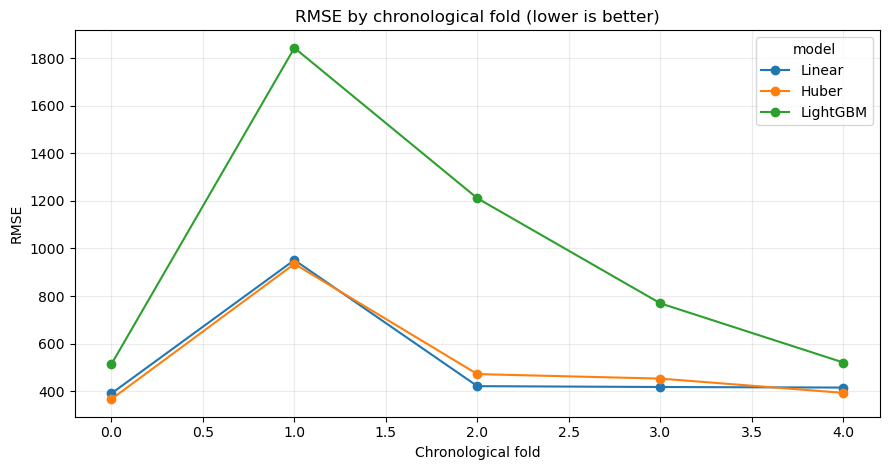

In [6]:
rmse_plot = fold_metrics.pivot(index='fold', columns='model', values='rmse')[list(MODEL_ORDER)]
ax = rmse_plot.plot(marker='o', figsize=(9, 4.8), title='RMSE by chronological fold (lower is better)')
ax.set_xlabel('Chronological fold')
ax.set_ylabel('RMSE')
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 5. 模型包、预测区间与输入检查函数

In [7]:
"""Build, persist, validate, and use the single online Champion artifact."""


from datetime import datetime, timezone
import hashlib
from pathlib import Path
import platform

import joblib
import lightgbm
import numpy as np
import pandas as pd
import sklearn



def _fingerprint(df: pd.DataFrame) -> str:
    hashed = pd.util.hash_pandas_object(df, index=True).to_numpy().tobytes()
    return hashlib.sha256(hashed).hexdigest()


def build_artifact(
    df: pd.DataFrame,
    model_name: str,
    model,
    cv_models: list,
    oof_predictions: np.ndarray,
    cv_summary: pd.DataFrame,
    optimizer_name: str | None = None,
    optimizer_config: dict | None = None,
) -> dict:
    valid = np.isfinite(oof_predictions)
    residuals = np.abs(df.loc[valid, TARGET_COL].to_numpy() - oof_predictions[valid])
    ranges = {
        column: {
            f"p{quantile}": float(df[column].quantile(quantile / 100))
            for quantile in (1, 5, 50, 95, 99)
        }
        for column in FEATURE_COLS
    }
    selected = cv_summary.loc[cv_summary["model"] == model_name].iloc[0]
    return {
        "artifact_version": "1.0",
        "created_at": datetime.now(timezone.utc).isoformat(),
        "model_name": model_name,
        "model": model,
        "cv_models": cv_models,
        "feature_cols": list(FEATURE_COLS),
        "target_col": TARGET_COL,
        "training_batches": int(len(df)),
        "training_data_fingerprint": _fingerprint(df[["batch_id"] + FEATURE_COLS + [TARGET_COL]]),
        "cv_metrics": cv_summary.to_dict(orient="records"),
        "selection_score": float(selected["selection_score"]),
        "conformal_abs_error_q90": float(np.quantile(residuals, 0.90)),
        "feature_ranges": ranges,
        "target_iqr": float(df[TARGET_COL].quantile(0.75) - df[TARGET_COL].quantile(0.25)),
        "training_reference": df[["batch_id"] + FEATURE_COLS + [TARGET_COL]].copy(),
        "optimizer_name": optimizer_name,
        "optimizer_config": optimizer_config or {},
        "versions": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__,
            "lightgbm": lightgbm.__version__,
        },
    }


def save_artifact(bundle: dict, path: str | Path) -> Path:
    destination = Path(path)
    if destination.suffix != ".joblib":
        raise ValueError("模型文件必须使用 .joblib 扩展名。")
    destination.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(bundle, destination)
    return destination


def load_artifact(path: str | Path) -> dict:
    source = Path(path)
    if source.suffix != ".joblib":
        raise ValueError("只允许加载可信的 .joblib 模型文件。")
    bundle = joblib.load(source)
    if not isinstance(bundle, dict) or bundle.get("artifact_version") != "1.0":
        raise ValueError("不支持的 Champion artifact。")
    return bundle


def validate_input(bundle: dict, frame: pd.DataFrame) -> pd.DataFrame:
    expected = list(bundle["feature_cols"])
    missing = [column for column in expected if column not in frame.columns]
    extra = [column for column in frame.columns if column not in expected]
    if missing:
        raise ValueError(f"输入缺少特征: {missing}")
    if extra:
        raise ValueError(f"输入包含额外特征: {extra}")
    numeric = frame[expected].apply(pd.to_numeric, errors="coerce")
    invalid = [column for column in expected if numeric[column].isna().any()]
    if invalid:
        raise ValueError(f"输入必须是完整数值，异常列: {invalid}")
    return numeric


def predict_with_interval(bundle: dict, frame: pd.DataFrame) -> pd.DataFrame:
    X = validate_input(bundle, frame)
    prediction = np.asarray(bundle["model"].predict(X), dtype=float)
    fold_predictions = np.vstack([model.predict(X) for model in bundle["cv_models"]])
    uncertainty = fold_predictions.std(axis=0)
    radius = float(bundle["conformal_abs_error_q90"])
    ood_features: list[str] = []
    row_ood: list[list[str]] = []
    for _, row in X.iterrows():
        flagged = []
        for column in bundle["feature_cols"]:
            bounds = bundle["feature_ranges"][column]
            if row[column] < bounds["p1"] or row[column] > bounds["p99"]:
                flagged.append(column)
        row_ood.append(flagged)
    return pd.DataFrame(
        {
            "predicted_gas": prediction,
            "prediction_lower_90": np.maximum(0, prediction - radius),
            "prediction_upper_90": prediction + radius,
            "ensemble_std": uncertainty,
            "is_ood": [bool(items) for items in row_ood],
            "ood_features": [", ".join(items) for items in row_ood],
        }
    )


## 6. 推荐上下文、可行性、随机搜索与遗传算法函数

In [8]:
"""Fair optimizer comparison with uncertainty and historical-feasibility penalties."""


from dataclasses import dataclass
import math

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler



WEIGHT_COL, SOLID_COL, MELTING_COL, WAIT_COL, DOOR_COUNT_COL, DOOR_DURATION_COL = FEATURE_COLS
CONTROLLABLE_COLS = [SOLID_COL, WAIT_COL, DOOR_COUNT_COL, DOOR_DURATION_COL]


@dataclass(frozen=True)
class SearchSpace:
    bounds: dict[str, tuple[float, float]]


def build_context(df: pd.DataFrame, total_weight: float, melting_time: float | None = None) -> dict:
    selected = pd.DataFrame()
    tolerance_used: float | None = None
    for tolerance in (0.05, 0.10):
        selected = df[df[WEIGHT_COL].between(total_weight * (1 - tolerance), total_weight * (1 + tolerance))]
        if len(selected) >= 20:
            tolerance_used = tolerance
            break
    low_confidence = False
    if len(selected) < 20:
        selected = df.copy()
        tolerance_used = None
        low_confidence = True
    if melting_time is None:
        melting_time = float(selected[MELTING_COL].median())
        melting_source = "similar_batch_median"
    else:
        melting_time = float(melting_time)
        melting_source = "user_input"
    return {
        "batches": selected.copy(),
        "total_weight": float(total_weight),
        "melting_time": melting_time,
        "melting_time_source": melting_source,
        "weight_tolerance": tolerance_used,
        "low_confidence": low_confidence,
    }


def build_search_space(context_df: pd.DataFrame) -> SearchSpace:
    bounds = {
        column: (float(context_df[column].quantile(0.05)), float(context_df[column].quantile(0.95)))
        for column in CONTROLLABLE_COLS
    }
    return SearchSpace(bounds=bounds)


def fit_feasibility_reference(df: pd.DataFrame) -> dict:
    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler()
    imputed = imputer.fit_transform(df[FEATURE_COLS])
    scaled = scaler.fit_transform(imputed)
    neighbors = min(6, len(df))
    nn = NearestNeighbors(n_neighbors=neighbors).fit(scaled)
    distances = nn.kneighbors(scaled, return_distance=True)[0]
    reference_index = min(5, distances.shape[1] - 1)
    threshold = float(np.quantile(distances[:, reference_index], 0.95))
    return {
        "imputer": imputer,
        "scaler": scaler,
        "neighbors": nn,
        "distance_threshold": max(threshold, 1e-12),
        "reference_rows": int(len(df)),
    }


def score_candidates(bundle: dict, candidates: pd.DataFrame, feasibility: dict, search_space: SearchSpace | None = None) -> pd.DataFrame:
    X = candidates[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
    if X.isna().any().any():
        raise ValueError("候选参数包含缺失或非数值。")
    result = candidates.reset_index(drop=True).copy()
    result["predicted_gas"] = np.asarray(bundle["model"].predict(X), dtype=float)
    fold_predictions = np.vstack([model.predict(X) for model in bundle["cv_models"]])
    result["prediction_std"] = fold_predictions.std(axis=0)

    scaled = feasibility["scaler"].transform(feasibility["imputer"].transform(X))
    n_neighbors = min(5, feasibility["reference_rows"])
    distance = feasibility["neighbors"].kneighbors(scaled, n_neighbors=n_neighbors, return_distance=True)[0][:, -1]
    normalized = distance / feasibility["distance_threshold"]
    result["normalized_knn_distance"] = normalized
    result["is_feasible"] = normalized <= 1.0
    result["penalized_objective"] = (
        result["predicted_gas"]
        + result["prediction_std"]
        + float(bundle["target_iqr"]) * np.maximum(0, normalized - 1)
    )

    result["boundary_hit_count"] = 0
    if search_space is not None:
        for column, (low, high) in search_space.bounds.items():
            width = max(high - low, 1e-12)
            hit = (result[column] - low <= 0.02 * width) | (high - result[column] <= 0.02 * width)
            result[f"boundary__{column}"] = hit
            result["boundary_hit_count"] += hit.astype(int)
    result["any_boundary_hit"] = result["boundary_hit_count"] > 0
    return result


def historical_fallback(context_df: pd.DataFrame) -> dict:
    count = max(1, int(math.ceil(len(context_df) * 0.20)))
    low_gas = context_df.sort_values(TARGET_COL).head(count)
    return {
        "source": "historical_similar_low_gas",
        "recommendation": {column: float(low_gas[column].median()) for column in CONTROLLABLE_COLS},
        "reference_batches": int(len(context_df)),
        "low_gas_batches": int(len(low_gas)),
        "actual_gas_median": float(low_gas[TARGET_COL].median()),
    }


def _sample_population(context: dict, space: SearchSpace, size: int, rng: np.random.Generator) -> pd.DataFrame:
    frame = pd.DataFrame(index=range(size))
    frame[WEIGHT_COL] = context["total_weight"]
    frame[MELTING_COL] = context["melting_time"]
    for column, (low, high) in space.bounds.items():
        if column == DOOR_COUNT_COL:
            integer_low = math.ceil(low)
            integer_high = math.floor(high)
            frame[column] = rng.integers(integer_low, integer_high + 1, size=size)
        else:
            frame[column] = rng.uniform(low, high, size=size)
    return frame[FEATURE_COLS]


def random_search(bundle: dict, context: dict, space: SearchSpace, feasibility: dict, budget: int = 5000, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    result = score_candidates(bundle, _sample_population(context, space, budget, rng), feasibility, space)
    result.attrs["search_bounds"] = dict(space.bounds)
    result.attrs["evaluations"] = int(budget)
    result.attrs["seed"] = int(seed)
    result.attrs["optimizer"] = "random_search"
    return result


def genetic_search(bundle: dict, context: dict, space: SearchSpace, feasibility: dict, budget: int = 5000, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    population_size = min(100, budget)
    generations = math.ceil(budget / population_size)
    population = _sample_population(context, space, population_size, rng)
    evaluated_parts: list[pd.DataFrame] = []

    for generation in range(generations):
        remaining = budget - sum(len(part) for part in evaluated_parts)
        if remaining <= 0:
            break
        current = population.iloc[:remaining].copy()
        scored = score_candidates(bundle, current, feasibility, space)
        scored["generation"] = generation
        evaluated_parts.append(scored)
        if remaining < population_size:
            break

        ranked = scored.sort_values(["is_feasible", "penalized_objective"], ascending=[False, True])
        elite_count = max(2, int(population_size * 0.20))
        elites = ranked.head(elite_count)[CONTROLLABLE_COLS].reset_index(drop=True)
        next_controls = [row.to_dict() for _, row in elites.iterrows()]
        while len(next_controls) < population_size:
            p1 = elites.iloc[int(rng.integers(0, len(elites)))]
            p2 = elites.iloc[int(rng.integers(0, len(elites)))]
            child = {}
            for column, (low, high) in space.bounds.items():
                if column == DOOR_COUNT_COL:
                    value = p1[column] if rng.random() < 0.5 else p2[column]
                    if rng.random() < 0.15:
                        value += rng.choice([-1, 1])
                    child[column] = int(np.clip(round(value), math.ceil(low), math.floor(high)))
                else:
                    alpha = rng.random()
                    value = alpha * p1[column] + (1 - alpha) * p2[column]
                    if rng.random() < 0.15:
                        value += rng.normal(0, 0.10 * (high - low))
                    child[column] = float(np.clip(value, low, high))
            next_controls.append(child)
        population = pd.DataFrame(next_controls)
        population[WEIGHT_COL] = context["total_weight"]
        population[MELTING_COL] = context["melting_time"]
        population = population[FEATURE_COLS]

    result = pd.concat(evaluated_parts, ignore_index=True).iloc[:budget].copy()
    result.attrs["search_bounds"] = dict(space.bounds)
    result.attrs["evaluations"] = int(len(result))
    result.attrs["seed"] = int(seed)
    result.attrs["optimizer"] = "genetic_algorithm"
    return result


def _best_objective(result: pd.DataFrame) -> float:
    feasible = result[result["is_feasible"]]
    pool = feasible if not feasible.empty else result
    return float(pool["penalized_objective"].min())


def compare_optimizers(
    bundle: dict,
    context: dict,
    space: SearchSpace,
    feasibility: dict,
    seeds=range(10),
    budget: int = 5000,
    tie_ratio: float = 0.005,
    keep_results: bool = True,
) -> dict:
    rows = []
    results: dict[tuple[str, int], pd.DataFrame] = {}
    best_rows = []
    for seed in seeds:
        for name, function in (("random_search", random_search), ("genetic_algorithm", genetic_search)):
            result = function(bundle, context, space, feasibility, budget=budget, seed=int(seed))
            if keep_results:
                results[(name, int(seed))] = result
            feasible = result[result["is_feasible"]]
            pool = feasible if not feasible.empty else result
            best = pool.sort_values("penalized_objective").iloc[0].to_dict()
            best.update(
                {
                    "optimizer": name,
                    "seed": int(seed),
                    "scenario_has_feasible": bool(not feasible.empty),
                }
            )
            best_rows.append(best)
            rows.append(
                {
                    "optimizer": name,
                    "seed": int(seed),
                    "best_objective": _best_objective(result),
                    "feasible_rate": float(result["is_feasible"].mean()),
                    "unique_candidates": int(result[CONTROLLABLE_COLS].drop_duplicates().shape[0]),
                }
            )
    runs = pd.DataFrame(rows)
    medians = runs.groupby("optimizer")["best_objective"].median()
    random_value = float(medians["random_search"])
    ga_value = float(medians["genetic_algorithm"])
    relative = abs(random_value - ga_value) / max(abs(random_value), 1e-12)
    if relative <= tie_ratio:
        selected = "random_search"
    else:
        selected = str(medians.idxmin())
    response = {
        "optimizer_name": selected,
        "runs": runs,
        "best_candidates": pd.DataFrame(best_rows),
        "median_objectives": medians.to_dict(),
    }
    if keep_results:
        response["results"] = results
    return response


def summarize_recommendation(result: pd.DataFrame, context: dict, top_n: int = 50) -> dict:
    feasible = result[result["is_feasible"]].sort_values("penalized_objective")
    if feasible.empty:
        return {"source": "no_feasible_model_candidate"}
    top = feasible.head(top_n)
    best = top.iloc[0]
    return {
        "source": "model_optimization",
        "recommendation": {column: float(top[column].median()) for column in CONTROLLABLE_COLS},
        "recommended_ranges_p25_p75": {
            column: [float(top[column].quantile(0.25)), float(top[column].quantile(0.75))]
            for column in CONTROLLABLE_COLS
        },
        "predicted_gas": float(best["predicted_gas"]),
        "prediction_std": float(best["prediction_std"]),
        "penalized_objective": float(best["penalized_objective"]),
        "normalized_knn_distance": float(best["normalized_knn_distance"]),
        "boundary_hit": bool(best["any_boundary_hit"]),
        "reference_melting_time": float(context["melting_time"]),
        "melting_time_source": context["melting_time_source"],
    }


## 7. 使用全部历史数据训练三个模型并建立 86000 kg 场景

In [9]:
context = build_context(df, TOTAL_WEIGHT)
search_space = build_search_space(context['batches'])
feasibility = fit_feasibility_reference(df)
target_iqr = float(df[TARGET_COL].quantile(.75) - df[TARGET_COL].quantile(.25))

bundles = {}
for model_name in MODEL_ORDER:
    bundles[model_name] = build_artifact(
        df=df,
        model_name=model_name,
        model=fit_champion(df, model_name),
        cv_models=evaluation['cv_models'][model_name],
        oof_predictions=evaluation['oof_predictions'][model_name],
        cv_summary=evaluation['summary'],
    )

context_summary = pd.DataFrame({
    '项目': ['目标总投料重量(kg)', '相似历史炉次数', '重量容差', '推荐使用熔炼时间', '熔炼时间来源', '低置信度'],
    '数值': [TOTAL_WEIGHT, len(context['batches']), context['weight_tolerance'], context['melting_time'], context['melting_time_source'], context['low_confidence']],
})
bounds_table = pd.DataFrame([
    {'可优化参数': col, '下限(P5)': low, '上限(P95)': high}
    for col, (low, high) in search_space.bounds.items()
])
display(context_summary)
display(bounds_table.round(4))

,项目,数值
0,目标总投料重量(kg),86000.0
1,相似历史炉次数,97
2,重量容差,0.05
3,推荐使用熔炼时间,8.74
4,熔炼时间来源,similar_batch_median
5,低置信度,False


,可优化参数,下限(P5),上限(P95)
0,10#熔炼炉固体料重量比例,27.116,63.996
1,熔炼炉B当前批次等待时长_PLC,0.388,2.450
2,熔炼炉B当前批次炉门打开次数_PLC,8.000,19.200
3,熔炼炉B当前批次炉门打开时长_PLC,39.000,139.000


## 8. 三模型分别比较随机搜索与遗传算法

三个模型和两个算法共享相同 P5–P95 边界、5000 次预算和种子0–9。

In [10]:
optimizer_rows = []
raw_rows = []
production_rows = []
fallback = historical_fallback(context['batches'])

for model_name in MODEL_ORDER:
    bundle = bundles[model_name]
    comparison = compare_optimizers(
        bundle, context, search_space, feasibility,
        seeds=SEEDS, budget=SEARCH_BUDGET, keep_results=False,
    )
    selected_optimizer = comparison['optimizer_name']
    for optimizer_name, group in comparison['runs'].groupby('optimizer'):
        optimizer_rows.append({
            'model': model_name,
            'optimizer': optimizer_name,
            'selected': optimizer_name == selected_optimizer,
            'median_best_objective': float(group['best_objective'].median()),
            'mean_feasible_rate': float(group['feasible_rate'].mean()),
            'median_unique_candidates': float(group['unique_candidates'].median()),
        })

    search_function = random_search if selected_optimizer == 'random_search' else genetic_search
    final_candidates = search_function(
        bundle, context, search_space, feasibility,
        budget=SEARCH_BUDGET, seed=FINAL_RECOMMENDATION_SEED,
    )
    recommendation = summarize_recommendation(final_candidates, context, top_n=50)
    has_model_result = recommendation['source'] == 'model_optimization'
    safety_pass = bool(
        has_model_result
        and not recommendation.get('boundary_hit', True)
        and recommendation.get('normalized_knn_distance', np.inf) <= 1.0
        and recommendation.get('prediction_std', np.inf) <= 0.50 * target_iqr
    )
    model_values = recommendation.get('recommendation', {})
    raw_rows.append({
        'model': model_name,
        'selected_optimizer': selected_optimizer,
        **{col: model_values.get(col, np.nan) for col in CONTROLLABLE_COLS},
        'predicted_gas': recommendation.get('predicted_gas', np.nan),
        'prediction_std': recommendation.get('prediction_std', np.nan),
        'penalized_objective': recommendation.get('penalized_objective', np.nan),
        'normalized_knn_distance': recommendation.get('normalized_knn_distance', np.nan),
        'boundary_hit': recommendation.get('boundary_hit', True),
        'safety_pass_86000': safety_pass,
    })

    production_values = model_values if safety_pass else fallback['recommendation']
    production_rows.append({
        'model': model_name,
        'production_source': 'model_optimization' if safety_pass else fallback['source'],
        **{col: production_values[col] for col in CONTROLLABLE_COLS},
        'warning': '' if safety_pass else '模型推荐未通过86000 kg单场景安全门，使用历史相似低气耗兜底',
    })

optimizer_summary = pd.DataFrame(optimizer_rows).sort_values(['model', 'optimizer']).reset_index(drop=True)
raw_recommendations = pd.DataFrame(raw_rows)
production_recommendations = pd.DataFrame(production_rows)

In [11]:
print('三模型 × 两优化算法比较（selected=True 为该模型选中的算法）')
display(optimizer_summary.round(4))

print('三个模型的原始参数推荐（离线比较保留，不因安全门而隐藏）')
display(raw_recommendations.round(4))

fallback_table = pd.DataFrame([{
    'source': fallback['source'],
    'reference_batches': fallback['reference_batches'],
    'low_gas_batches': fallback['low_gas_batches'],
    'actual_gas_median': fallback['actual_gas_median'],
    **fallback['recommendation'],
}])
print('历史相似低气耗兜底基准')
display(fallback_table.round(4))

print('经过86000 kg单场景安全门后的可用推荐')
display(production_recommendations.round(4))

三模型 × 两优化算法比较（selected=True 为该模型选中的算法）


,model,optimizer,selected,median_best_objective,mean_feasible_rate,median_unique_candidates
0,Huber,genetic_algorithm,True,3021.9468,1.0,2133.0
1,Huber,random_search,False,3070.7093,1.0,5000.0
2,LightGBM,genetic_algorithm,False,3068.7488,1.0,3914.5
3,LightGBM,random_search,True,3082.2024,1.0,5000.0
4,Linear,genetic_algorithm,True,3128.6681,1.0,2037.5
5,Linear,random_search,False,3156.7346,1.0,5000.0


三个模型的原始参数推荐（离线比较保留，不因安全门而隐藏）


,model,selected_optimizer,10#熔炼炉固体料重量比例,熔炼炉B当前批次等待时长_PLC,熔炼炉B当前批次炉门打开次数_PLC,熔炼炉B当前批次炉门打开时长_PLC,predicted_gas,prediction_std,penalized_objective,normalized_knn_distance,boundary_hit,safety_pass_86000
0,Linear,genetic_algorithm,27.1160,0.3880,19.0,39.0000,3106.1265,22.5416,3128.6681,0.4833,True,False
1,Huber,genetic_algorithm,27.1160,0.3880,19.0,39.0000,2993.2522,28.6947,3021.9468,0.4833,True,False
2,LightGBM,random_search,29.0496,0.8179,15.0,92.3089,2519.8408,554.7197,3074.5606,0.4260,True,False


历史相似低气耗兜底基准


,source,reference_batches,low_gas_batches,actual_gas_median,10#熔炼炉固体料重量比例,熔炼炉B当前批次等待时长_PLC,熔炼炉B当前批次炉门打开次数_PLC,熔炼炉B当前批次炉门打开时长_PLC
0,historical_similar_low_gas,97,20,2876.395,40.06,0.65,14.0,69.5


经过86000 kg单场景安全门后的可用推荐


,model,production_source,10#熔炼炉固体料重量比例,熔炼炉B当前批次等待时长_PLC,熔炼炉B当前批次炉门打开次数_PLC,熔炼炉B当前批次炉门打开时长_PLC,warning
0,Linear,historical_similar_low_gas,40.06,0.65,14.0,69.5,模型推荐未通过86000 kg单场景安全门，使用历史相似低气耗兜底
1,Huber,historical_similar_low_gas,40.06,0.65,14.0,69.5,模型推荐未通过86000 kg单场景安全门，使用历史相似低气耗兜底
2,LightGBM,historical_similar_low_gas,40.06,0.65,14.0,69.5,模型推荐未通过86000 kg单场景安全门，使用历史相似低气耗兜底


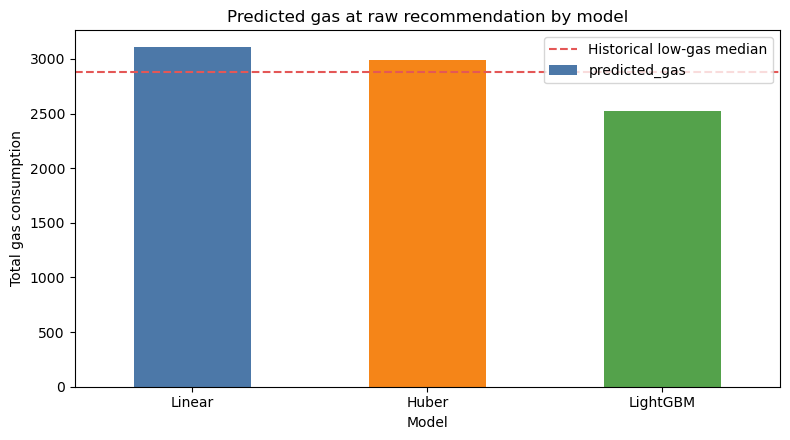

In [12]:
plot_data = raw_recommendations.set_index('model')['predicted_gas'].reindex(MODEL_ORDER)
ax = plot_data.plot(kind='bar', figsize=(8, 4.5), color=['#4C78A8', '#F58518', '#54A24B'], title='Predicted gas at raw recommendation by model')
ax.axhline(fallback['actual_gas_median'], color='#E45756', linestyle='--', label='Historical low-gas median')
ax.set_ylabel('Total gas consumption')
ax.set_xlabel('Model')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. 自动结论

预测 Champion 由时间滚动验证决定；三个模型的原始推荐全部保留，未通过安全门时生产候选使用历史低气耗兜底。

In [13]:
champion_row = model_summary.sort_values('selection_score').iloc[0]
safe_models = raw_recommendations.loc[raw_recommendations['safety_pass_86000'], 'model'].tolist()
print(f"预测 Champion: {champion_row['model']}")
print(f"Champion 平均RMSE: {champion_row['rmse_mean']:.2f}")
print(f"Champion 选择分数: {champion_row['selection_score']:.2f}")
print(f"86000 kg 单场景通过安全门的模型: {safe_models if safe_models else '无'}")
print('注意：原始模型推荐用于离线比较；生产建议应优先采用 production_recommendations 表中的安全结果或历史兜底。')

预测 Champion: Linear
Champion 平均RMSE: 519.06
Champion 选择分数: 579.52
86000 kg 单场景通过安全门的模型: 无
注意：原始模型推荐用于离线比较；生产建议应优先采用 production_recommendations 表中的安全结果或历史兜底。


## 10. 可选导出 joblib

默认不写文件。将顶部 `EXPORT_JOBLIB` 改为 `True` 后重新运行本单元，会导出 `artifacts/three_model_standalone.joblib`，不会覆盖正式 Champion。

In [14]:
export_bundle = {
    'artifact_version': 'standalone-three-model-1.0',
    'created_at': datetime.now(timezone.utc).isoformat(),
    'feature_cols': list(FEATURE_COLS),
    'target_col': TARGET_COL,
    'training_batches': int(len(df)),
    'models': {name: bundles[name]['model'] for name in MODEL_ORDER},
    'cv_models': {name: bundles[name]['cv_models'] for name in MODEL_ORDER},
    'model_summary': evaluation['summary'].copy(),
    'fold_metrics': fold_metrics.copy(),
    'optimizer_summary_86000': optimizer_summary.copy(),
    'raw_recommendations_86000': raw_recommendations.copy(),
    'production_recommendations_86000': production_recommendations.copy(),
    'recommendation_total_weight': TOTAL_WEIGHT,
}

if EXPORT_JOBLIB:
    EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(export_bundle, EXPORT_PATH)
    print(f'已导出: {EXPORT_PATH.resolve()}')
else:
    print('EXPORT_JOBLIB=False：本次测试不写模型文件。如需导出，请改为 True 后重新运行本单元。')


EXPORT_JOBLIB=False：本次测试不写模型文件。如需导出，请改为 True 后重新运行本单元。
